# Notebook 1: Data Acquisition

## Stock Price Forecasting Application

---

**Objective:** Collect historical stock price data from Yahoo Finance for multiple publicly traded companies and perform initial exploratory data analysis (EDA) to understand the data's structure, distributions, and potential for forecasting.

**Data Source:** Yahoo Finance via the `yfinance` Python library

**Stocks Selected:**
- AAPL (Apple Inc.)
- MSFT (Microsoft Corp.)
- GOOGL (Alphabet Inc.)
- AMZN (Amazon.com Inc.)
- TSLA (Tesla Inc.)

**Rationale:** These are high-volume, widely followed technology stocks with rich historical data. They represent diverse sub-sectors (consumer electronics, cloud computing, digital advertising, e-commerce, and electric vehicles), providing a broad view of market dynamics.

## 1.1 Import Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Data acquisition
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('All libraries imported successfully.')

All libraries imported successfully.


## 1.2 Define Stock Tickers and Download Data

We collect 10 years of daily historical data (2015–2025) for each stock. This provides a substantial dataset (~2,500 trading days per stock) that spans multiple market cycles, including bull runs, corrections, and the COVID-19 volatility period.

In [2]:
# Define tickers and date range
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
START_DATE = '2015-01-01'
END_DATE = '2025-01-01'

# Download data for all tickers
stock_data = {}
for ticker in TICKERS:
    print(f'Downloading {ticker}...')
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Ticker'] = ticker
    stock_data[ticker] = df
    print(f'  {ticker}: {len(df)} records from {df.index.min().date()} to {df.index.max().date()}')

print(f'\nDownload complete. {len(stock_data)} stocks acquired.')

  AAPL: 2516 records from 2015-01-02 to 2024-12-31
  MSFT: 2516 records from 2015-01-02 to 2024-12-31
  GOOGL: 2516 records from 2015-01-02 to 2024-12-31
  AMZN: 2516 records from 2015-01-02 to 2024-12-31
  TSLA: 2516 records from 2015-01-02 to 2024-12-31

Download complete. 5 stocks acquired.


## 1.3 Combine and Inspect the Data

In [3]:
# Combine all stock data into a single DataFrame
all_stocks = pd.concat(stock_data.values(), axis=0)
all_stocks.index.name = 'Date'

print(f'Combined dataset shape: {all_stocks.shape}')
print(f'Date range: {all_stocks.index.min().date()} to {all_stocks.index.max().date()}')
print(f'\nTickers included: {all_stocks["Ticker"].unique()}')
print(f'\nColumn names: {list(all_stocks.columns)}')
all_stocks.head(10)

Combined dataset shape: (12580, 6)
Date range: 2015-01-02 to 2024-12-31

Tickers included: <StringArray>
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
Length: 5, dtype: str

Column names: ['Close', 'High', 'Low', 'Open', 'Volume', 'Ticker']


Price,Close,High,Low,Open,Volume,Ticker
Date,,,,,,
2015-01-02,24.21,24.68,23.78,24.67,212818400,AAPL
2015-01-05,23.53,24.06,23.35,23.98,257142000,AAPL
2015-01-06,23.53,23.79,23.17,23.60,263188400,AAPL
2015-01-07,23.86,23.96,23.63,23.74,160423600,AAPL
2015-01-08,24.78,24.84,24.08,24.19,237458000,AAPL
2015-01-09,24.81,25.08,24.41,24.95,214798000,AAPL
2015-01-12,24.20,24.95,24.10,24.94,198603200,AAPL
2015-01-13,24.41,24.98,24.12,24.68,268367600,AAPL
2015-01-14,24.32,24.47,24.03,24.15,195826400,AAPL


In [4]:
# Data types and basic info
all_stocks.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 12580 entries, 2015-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   12580 non-null  float64
 1   High    12580 non-null  float64
 2   Low     12580 non-null  float64
 3   Open    12580 non-null  float64
 4   Volume  12580 non-null  int64  
 5   Ticker  12580 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 688.0 KB


In [5]:
# Summary statistics for each stock
for ticker in TICKERS:
    print(f'\n{"="*60}')
    print(f'Summary Statistics: {ticker}')
    print(f'{"="*60}')
    display(stock_data[ticker][['Open', 'High', 'Low', 'Close', 'Volume']].describe())


Summary Statistics: AAPL


Price,Open,High,Low,Close,Volume
count,2516.00,2516.00,2516.00,2516.00,2516.00
mean,93.68,94.68,92.76,93.77,117085320.35
std,65.30,65.97,64.69,65.38,68396140.39
min,20.51,20.89,20.39,20.58,23234700.00
25%,35.21,35.59,34.81,35.19,71056100.00
50%,64.17,64.88,63.53,64.33,100364650.00
75%,149.92,151.84,148.13,150.09,142621625.00
max,256.79,258.69,256.23,257.61,648825200.00



Summary Statistics: MSFT


Price,Open,High,Low,Close,Volume
count,2516.00,2516.00,2516.00,2516.00,2516.00
mean,180.22,181.93,178.42,180.26,28879379.33
std,122.68,123.74,121.51,122.68,13362953.76
min,34.52,34.89,34.21,34.36,7164500.00
25%,64.38,65.03,63.87,64.56,20609775.00
50%,144.20,147.40,143.16,145.55,25724700.00
75%,274.70,277.60,271.02,274.14,33158400.00
max,460.77,462.10,458.26,461.32,169164000.00



Summary Statistics: GOOGL


Price,Open,High,Low,Close,Volume
count,2516.00,2516.00,2516.00,2516.00,2516.00
mean,82.02,82.89,81.18,82.06,35174792.45
std,43.40,43.89,42.94,43.42,16993787.82
min,24.76,24.81,24.34,24.65,9312000.00
25%,46.98,47.25,46.62,46.99,24745500.00
50%,64.00,64.51,63.41,64.18,30951000.00
75%,118.69,120.05,117.62,118.72,40071000.00
max,196.34,200.49,194.08,195.76,257162000.00



Summary Statistics: AMZN


Price,Open,High,Low,Close,Volume
count,2516.00,2516.00,2516.00,2516.00,2516.00
mean,101.26,102.41,100.00,101.23,76144988.67
std,54.20,54.82,53.53,54.17,40619660.28
min,14.31,14.54,14.26,14.35,15007500.00
25%,48.58,48.83,48.09,48.40,50710225.00
50%,94.56,95.56,93.45,94.57,65262000.00
75%,153.88,155.91,151.73,153.86,90088000.00
max,232.39,233.00,228.01,232.93,477122000.00



Summary Statistics: TSLA


Price,Open,High,Low,Close,Volume
count,2516.00,2516.00,2516.00,2516.00,2516.00
mean,115.70,118.25,112.99,115.68,112313098.69
std,114.31,116.89,111.49,114.23,74070877.96
min,9.49,10.33,9.40,9.58,10620000.00
25%,17.18,17.48,16.89,17.19,66818850.00
50%,28.41,28.81,27.35,28.51,92845850.00
75%,220.93,225.35,215.34,220.21,129788625.00
max,475.90,488.54,457.51,479.86,914082000.00


## 1.4 Check for Missing Values

Missing values in stock data can result from market holidays, trading halts, or data source issues. Understanding the extent of missing data is critical before preprocessing.

In [6]:
# Check missing values per ticker
print('Missing Values by Ticker and Column:\n')
for ticker in TICKERS:
    missing = stock_data[ticker].isnull().sum()
    total = len(stock_data[ticker])
    print(f'{ticker} ({total} rows):')
    for col in missing.index:
        if col != 'Ticker':
            pct = (missing[col] / total) * 100
            print(f'  {col}: {missing[col]} missing ({pct:.2f}%)')
    print()

Missing Values by Ticker and Column:

AAPL (2516 rows):
  Close: 0 missing (0.00%)
  High: 0 missing (0.00%)
  Low: 0 missing (0.00%)
  Open: 0 missing (0.00%)
  Volume: 0 missing (0.00%)

MSFT (2516 rows):
  Close: 0 missing (0.00%)
  High: 0 missing (0.00%)
  Low: 0 missing (0.00%)
  Open: 0 missing (0.00%)
  Volume: 0 missing (0.00%)

GOOGL (2516 rows):
  Close: 0 missing (0.00%)
  High: 0 missing (0.00%)
  Low: 0 missing (0.00%)
  Open: 0 missing (0.00%)
  Volume: 0 missing (0.00%)

AMZN (2516 rows):
  Close: 0 missing (0.00%)
  High: 0 missing (0.00%)
  Low: 0 missing (0.00%)
  Open: 0 missing (0.00%)
  Volume: 0 missing (0.00%)

TSLA (2516 rows):
  Close: 0 missing (0.00%)
  High: 0 missing (0.00%)
  Low: 0 missing (0.00%)
  Open: 0 missing (0.00%)
  Volume: 0 missing (0.00%)



## 1.5 Exploratory Data Analysis (EDA)

### 1.5.1 Closing Price Trends Over Time

Visualizing the closing price history for all stocks helps us understand overall trends, relative price levels, and periods of high volatility.

In [7]:
# Interactive closing price chart for all stocks
fig = go.Figure()
for ticker in TICKERS:
    fig.add_trace(go.Scatter(
        x=stock_data[ticker].index,
        y=stock_data[ticker]['Close'],
        mode='lines',
        name=ticker
    ))

fig.update_layout(
    title='Historical Closing Prices (2015–2025)',
    xaxis_title='Date',
    yaxis_title='Closing Price (USD)',
    template='plotly_white',
    height=500,
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01)
)
fig.show()

### 1.5.2 Trading Volume Analysis

Volume indicates market activity and liquidity. High-volume periods often coincide with significant price movements.

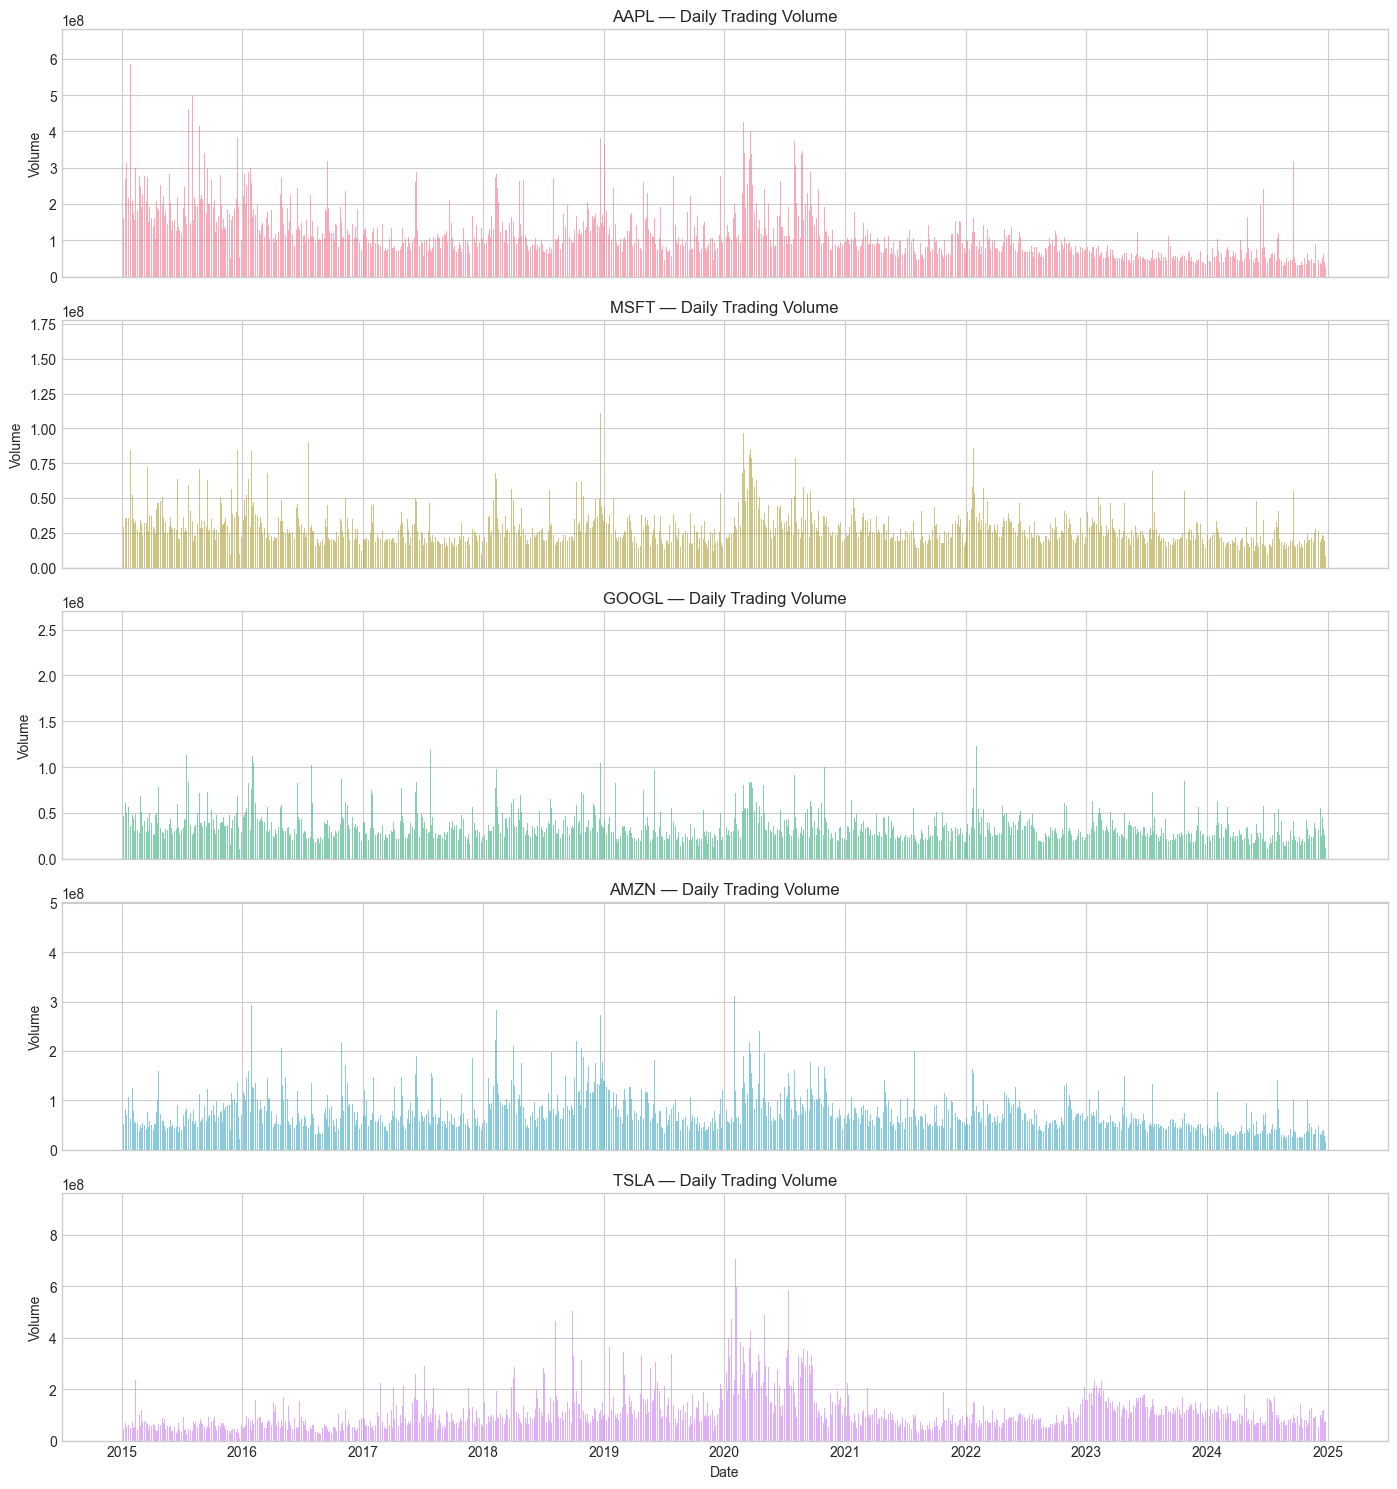

In [8]:
# Volume comparison across stocks
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 3 * len(TICKERS)), sharex=True)

for i, ticker in enumerate(TICKERS):
    axes[i].bar(stock_data[ticker].index, stock_data[ticker]['Volume'],
                width=1, alpha=0.6, color=sns.color_palette('husl', len(TICKERS))[i])
    axes[i].set_ylabel('Volume')
    axes[i].set_title(f'{ticker} — Daily Trading Volume')
    axes[i].ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))

plt.xlabel('Date')
plt.tight_layout()
plt.show()

### 1.5.3 Daily Returns Distribution

Daily returns reveal the volatility characteristics of each stock. We compute the percentage change in closing price from one day to the next.

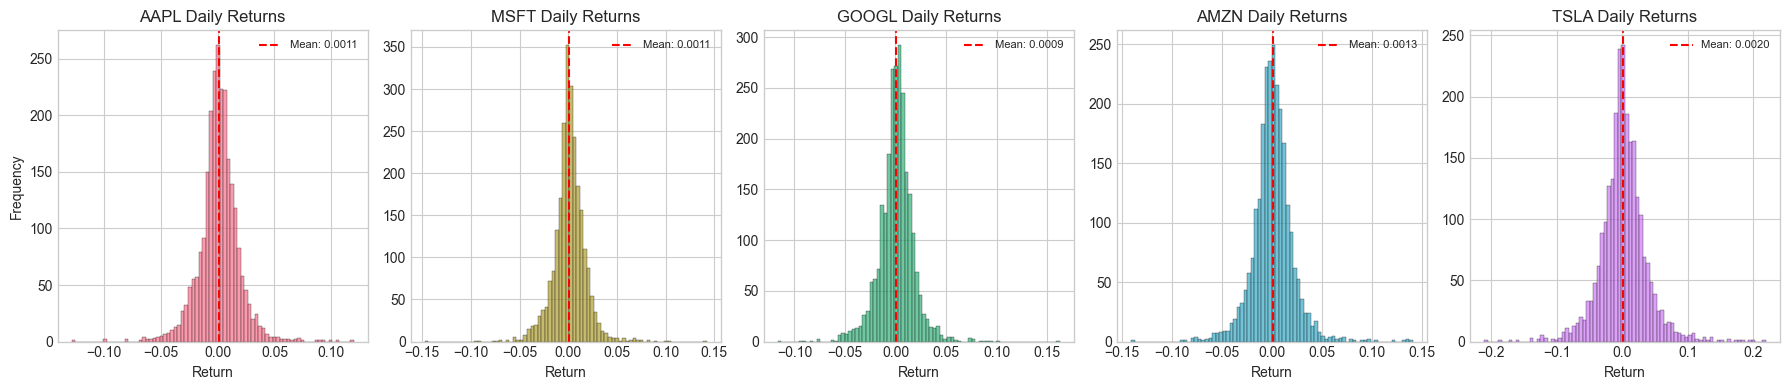

In [9]:
# Calculate daily returns for each stock
fig, axes = plt.subplots(1, len(TICKERS), figsize=(18, 4))

for i, ticker in enumerate(TICKERS):
    returns = stock_data[ticker]['Close'].pct_change().dropna()
    axes[i].hist(returns, bins=80, alpha=0.7, color=sns.color_palette('husl', len(TICKERS))[i],
                 edgecolor='black', linewidth=0.3)
    axes[i].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
    axes[i].set_title(f'{ticker} Daily Returns')
    axes[i].set_xlabel('Return')
    axes[i].legend(fontsize=8)

axes[0].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### 1.5.4 Correlation Analysis

Examining how stock prices move relative to each other helps identify common market factors and diversification opportunities.

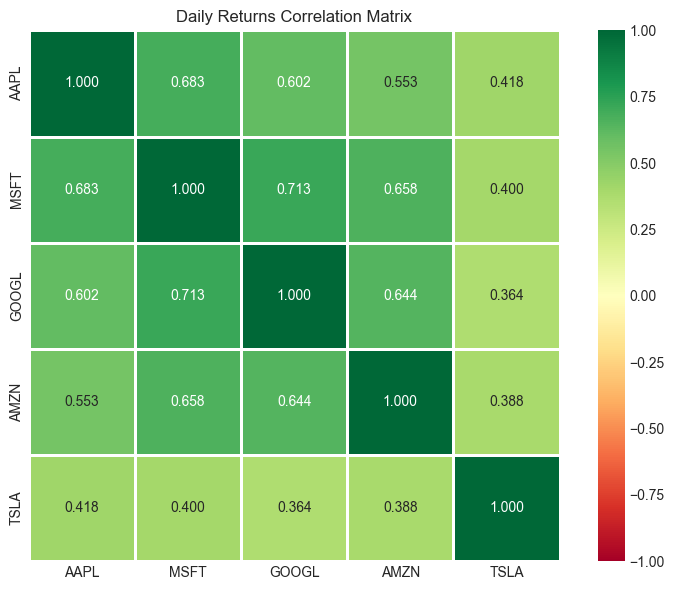


Correlation Matrix (Daily Returns):


,AAPL,MSFT,GOOGL,AMZN,TSLA
AAPL,1.00,0.68,0.60,0.55,0.42
MSFT,0.68,1.00,0.71,0.66,0.40
GOOGL,0.60,0.71,1.00,0.64,0.36
AMZN,0.55,0.66,0.64,1.00,0.39
TSLA,0.42,0.40,0.36,0.39,1.00


In [10]:
# Build a DataFrame of closing prices for correlation
close_prices = pd.DataFrame()
for ticker in TICKERS:
    close_prices[ticker] = stock_data[ticker]['Close']

# Compute correlation matrix on daily returns
returns_df = close_prices.pct_change().dropna()
corr_matrix = returns_df.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=1, vmin=-1, vmax=1)
plt.title('Daily Returns Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelation Matrix (Daily Returns):')
display(corr_matrix)

### 1.5.5 Normalized Price Comparison

To compare stocks on a common scale, we normalize all prices to start at 100 on the first date, showing relative growth.

In [11]:
# Normalized prices (base = 100)
normalized = close_prices.div(close_prices.iloc[0]).mul(100)

fig = go.Figure()
for ticker in TICKERS:
    fig.add_trace(go.Scatter(
        x=normalized.index,
        y=normalized[ticker],
        mode='lines',
        name=ticker
    ))

fig.update_layout(
    title='Normalized Stock Prices (Base = 100)',
    xaxis_title='Date',
    yaxis_title='Normalized Price',
    template='plotly_white',
    height=500
)
fig.show()

### 1.5.6 Candlestick Chart — AAPL (Focus Stock)

A candlestick chart for the most recent year of AAPL data provides a detailed view of price action including open, high, low, and close.

In [13]:
# Candlestick chart for AAPL (last 6 months)
aapl_data = stock_data['AAPL']
aapl_recent = aapl_data[aapl_data.index >= aapl_data.index.max() - pd.DateOffset(months=6)]

fig = go.Figure(data=[go.Candlestick(
    x=aapl_recent.index,
    open=aapl_recent['Open'],
    high=aapl_recent['High'],
    low=aapl_recent['Low'],
    close=aapl_recent['Close'],
    name='AAPL'
)])

fig.update_layout(
    title='AAPL Candlestick Chart (Last 6 Months)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_white',
    height=500,
    xaxis_rangeslider_visible=False
)
fig.show()

### 1.5.7 Rolling Volatility

30-day rolling standard deviation of daily returns shows how volatility evolves over time.

In [14]:
# Rolling 30-day volatility
fig = go.Figure()
for ticker in TICKERS:
    rolling_vol = returns_df[ticker].rolling(window=30).std() * np.sqrt(252)  # Annualized
    fig.add_trace(go.Scatter(
        x=rolling_vol.index,
        y=rolling_vol,
        mode='lines',
        name=ticker
    ))

fig.update_layout(
    title='30-Day Rolling Annualized Volatility',
    xaxis_title='Date',
    yaxis_title='Annualized Volatility',
    template='plotly_white',
    height=500
)
fig.show()

## 1.6 Save Raw Data

Save each stock's data to CSV for use in subsequent notebooks. We also save the combined dataset.

In [15]:
# Create data directory if it doesn't exist
data_dir = os.path.join('..', 'data')
os.makedirs(data_dir, exist_ok=True)

# Save individual stock data
for ticker in TICKERS:
    filepath = os.path.join(data_dir, f'{ticker}_raw.csv')
    stock_data[ticker].to_csv(filepath)
    print(f'Saved {ticker} data to {filepath} ({len(stock_data[ticker])} rows)')

# Save combined dataset
combined_path = os.path.join(data_dir, 'all_stocks_raw.csv')
all_stocks.to_csv(combined_path)
print(f'\nSaved combined dataset to {combined_path} ({len(all_stocks)} rows)')

Saved AAPL data to ..\data\AAPL_raw.csv (2516 rows)
Saved MSFT data to ..\data\MSFT_raw.csv (2516 rows)
Saved GOOGL data to ..\data\GOOGL_raw.csv (2516 rows)
Saved AMZN data to ..\data\AMZN_raw.csv (2516 rows)
Saved TSLA data to ..\data\TSLA_raw.csv (2516 rows)

Saved combined dataset to ..\data\all_stocks_raw.csv (12580 rows)


## 1.7 Key Takeaways from Data Acquisition

1. **Data quality is strong** — Yahoo Finance provides complete OHLCV data with minimal missing values for these liquid stocks.
2. **All five stocks show significant upward trends** over the 10-year period, with TSLA exhibiting the most dramatic growth and highest volatility.
3. **Stocks are moderately to highly correlated** in terms of daily returns, which is expected for stocks within the technology sector.
4. **Volatility spikes** are visible around major market events (e.g., COVID-19 crash in March 2020), suggesting that models should be robust to regime changes.
5. **AAPL will serve as the primary focus** for detailed modeling in subsequent notebooks due to its high liquidity and representative price behavior.

---

**Next Step:** Proceed to Notebook 02 — Data Preprocessing, where we will clean the data, engineer technical indicator features, and prepare the dataset for modeling.